# 01.1. Comparación de encoders

Comparar recuperación sobre el corpus completo con las 50 preguntas oficiales. Se prueban primero los encoders recomendados. La referencia se consulta después de recuperar, solo para medir coincidencias de normas.

Recall de normas no mide corrección jurídica ni garantiza recuperar el artículo adecuado. Las preguntas sin citas extraíbles quedan fuera de esa métrica. Los resultados son de desarrollo, no una evaluación independiente.

## Entorno

Los datos se extraen al disco de la sesión. Los resultados nuevos se guardan en Drive mientras avanza la ejecución. Los modelos se descargan al disco de Colab. Si se elimina la sesión, se descargan de nuevo.

In [1]:
from pathlib import Path
import hashlib
import importlib.metadata
import json
import os
import shutil
import subprocess
import sys
import zipfile

# Solo PyTorch: evita que transformers cargue TensorFlow/JAX de Colab
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["USE_FLAX"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"

MODO = "auto"
CARPETA_DRIVE = "/content/drive/MyDrive/AIWEEK"
try:
    import google.colab
    detectado_colab = True
except ImportError:
    detectado_colab = False
if MODO not in {"auto", "local", "colab"}:
    raise ValueError("MODO debe ser auto, local o colab")
EN_COLAB = detectado_colab if MODO == "auto" else MODO == "colab"

def hash_archivo(ruta):
    h = hashlib.sha256()
    with Path(ruta).open("rb") as archivo:
        for bloque in iter(lambda: archivo.read(8 * 1024 * 1024), b""):
            h.update(bloque)
    return h.hexdigest()

if EN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE = Path(CARPETA_DRIVE)
    paquete_drive = DRIVE / "ai-week-colab.zip"
    if not paquete_drive.is_file():
        raise FileNotFoundError(f"Subir ai-week-colab.zip a {DRIVE}")
    paquete = Path("/content/ai-week-colab.zip")
    shutil.copy2(paquete_drive, paquete)
    huella_paquete = hash_archivo(paquete)
    raiz = Path("/content/aiweek") / huella_paquete[:12]
    if not (raiz / ".paquete_verificado").is_file():
        raiz.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(paquete) as z:
            for nombre in z.namelist():
                if not (raiz / nombre).resolve().is_relative_to(raiz.resolve()):
                    raise ValueError("Ruta inválida dentro del ZIP")
            z.extractall(raiz)
        inventario = json.loads((raiz / "paquete.json").read_text(encoding="utf-8"))
        for nombre, esperado in inventario["sha256_archivos"].items():
            if hash_archivo(raiz / nombre) != esperado:
                raise ValueError(f"Archivo incompleto: {nombre}")
        (raiz / ".paquete_verificado").write_text(huella_paquete)
    dependencias = raiz / "requirements/colab.txt"
    marca = Path("/content/aiweek_dependencias_v2.sha256")
    version_deps = hash_archivo(dependencias)
    if not marca.exists() or marca.read_text() != version_deps:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(dependencias)], check=True)
        # Colab trae librerías compiladas para numpy 2; numpy 1.x rompe transformers (StringDType)
        if int(importlib.metadata.version("numpy").split(".")[0]) < 2:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpy>=2"], check=True)
        marca.write_text(version_deps)
    for nombre in ("numpy", "pandas", "transformers", "tokenizers"):
        if nombre in sys.modules and getattr(sys.modules[nombre], "__version__", None) != importlib.metadata.version(nombre):
            raise RuntimeError("Reiniciar la sesión de Colab y ejecutar desde el principio para cargar las versiones instaladas")
    RESULTADOS = DRIVE / "resultados" / huella_paquete[:12]
else:
    raiz = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "configs/modelos.json").is_file()), None)
    if raiz is None:
        raise FileNotFoundError("Abrir el notebook desde la carpeta del proyecto o notebooks")
    RESULTADOS = raiz / "data/experimentos_oficiales"
RAIZ = raiz
RESULTADOS.mkdir(parents=True, exist_ok=True)
if EN_COLAB:
    corpus_drive = RESULTADOS / "corpus_procesado.zip"
    marca_corpus = raiz / ".corpus_restaurado"
    if corpus_drive.is_file():
        huella_corpus = hash_archivo(corpus_drive)
        if not marca_corpus.exists() or marca_corpus.read_text() != huella_corpus:
            carpeta_corpus = raiz / "data/processed/corpus"
            with zipfile.ZipFile(corpus_drive) as z:
                for nombre in z.namelist():
                    if not (carpeta_corpus / nombre).resolve().is_relative_to(carpeta_corpus.resolve()):
                        raise ValueError("Ruta inválida en el corpus guardado")
                z.extractall(carpeta_corpus)
            marca_corpus.write_text(huella_corpus)
os.chdir(raiz)
sys.path.insert(0, str(raiz / "src"))
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ["HF_HOME"] = str(raiz / "data/cache_huggingface") if EN_COLAB else os.environ.get("HF_HOME", str(Path.home() / ".cache/huggingface"))
print("Entorno:", "Colab" if EN_COLAB else "local")
print("Proyecto:", raiz)
print("Resultados:", RESULTADOS)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Entorno: Colab
Proyecto: /content/aiweek/915505e96337
Resultados: /content/drive/MyDrive/AIWEEK/resultados/915505e96337


In [2]:
import gc
import time
import pandas as pd
import matplotlib.pyplot as plt
import torch
from legalrag.evaluation.oficial import (cargar_muestra, cargar_citaciones, metricas_recuperacion,
                                      consulta, guardar_json, huellas, abrir_experimento)
from legalrag.encoding.encoder import Encoder
from legalrag.retrieval.recuperador import BM25
from legalrag.indexing.indice import construir_indice, cargar_corpus
from legalrag.comun import leer_jsonl, hash_json, sha256
from legalrag.generation.runtime import hardware

catalogo = json.loads((raiz / "configs/modelos.json").read_text(encoding="utf-8"))
device = "cuda" if torch.cuda.is_available() else "cpu"
precision = "float16" if device == "cuda" else "float32"
batch_size = 32 if device == "cuda" and torch.cuda.get_device_properties(0).total_memory >= 30 * 2**30 else 4
print(hardware() if device == "cuda" else "CPU")
print("PyTorch:", torch.__version__, "Lote:", batch_size)

NVIDIA L4, 23034 MiB, 8.9
PyTorch: 2.11.0+cu128 Lote: 4


In [3]:
modelos = ["multilingual-e5-large", "bge-m3", "jina-embeddings-v3", "multilingual-e5-base"]
tamanos = [320]
solapamiento = 32
reanudar = ""

muestra, entradas = cargar_muestra(raiz)
citas = cargar_citaciones(raiz)
docs = {d["doc_id"]: d for d in leer_jsonl(raiz / "data/processed/corpus/documentos.jsonl")}
configuracion = {"modelos": modelos, "tamanos": tamanos, "solapamiento": solapamiento,
                 "batch_size": batch_size, "precision": precision, "device": device,
                 "hardware": hardware() if device == "cuda" else "cpu", "torch": torch.__version__,
                 "huellas": huellas(raiz)}
carpeta = abrir_experimento(RESULTADOS, "encoders", configuracion, reanudar)
display(pd.DataFrame(catalogo["encoders"])[["nombre", "licencia", "recomendado", "revision"]])
print("Ejecución:", carpeta.name)

,nombre,licencia,recomendado,revision
0,multilingual-e5-large,mit,True,3d7cfbdacd47fdda877c5cd8a79fbcc4f2a574f3
1,bge-m3,mit,True,5617a9f61b028005a4858fdac845db406aefb181
2,jina-embeddings-v3,cc-by-nc-4.0,True,ab036b023d30b4d1138c4c3bfa9f0c445ab455d6
3,multilingual-e5-base,mit,False,d128750597153bb5987e10b1c3493a34e5a4502a


Ejecución: 20260927T191142912733Z


## Medición

El tamaño inicial es 320 tokens. Se puede ampliar tamanos para comparar otras ventanas en una ejecución nueva. Jina usa una licencia no comercial, tal como indica su ficha.

Se guarda cada combinación terminada. Para continuar después de una desconexión, copiar el nombre de la ejecución en reanudar. Los índices se comprimen en Drive y se pueden reutilizar desde 02.

In [4]:
filas = []
for ficha in sorted(catalogo["encoders"], key=lambda f: f["prioridad"]):
    if ficha["nombre"] not in modelos:
        continue
    pendientes = [t for t in tamanos if not (carpeta / f"{ficha['nombre']}_{t}_resumen.json").exists()]
    if pendientes:
        encoder = Encoder(ficha, device, precision)
    for tamano in tamanos:
        etiqueta = f"{ficha['nombre']}_{tamano}"
        guardado = carpeta / f"{etiqueta}_resumen.json"
        if guardado.exists():
            filas.extend(json.loads(guardado.read_text(encoding="utf-8")))
            continue
        print("Indexando", etiqueta, flush=True)
        indice_local = raiz / "data/index/oficial" / carpeta.name / etiqueta
        config = {"encoder": ficha, "corpus": "data/processed/corpus", "tamano_tokens": tamano,
                  "solapamiento_tokens": solapamiento, "device": device, "precision": precision,
                  "batch_size": batch_size, "hibrido": False, "salida": str(indice_local)}
        manifiesto, recuperador = construir_indice(config, encoder)
        resumenes = []
        for hibrido in [False, True]:
            metodo = "hibrido" if hibrido else "denso"
            recuperador.bm25 = BM25([v["texto_busqueda"] for v in recuperador.ventanas]) if hibrido else None
            medidas = []
            for pregunta, entrada in zip(muestra, entradas):
                inicio = time.perf_counter()
                pasajes = recuperador.buscar(consulta(entrada), k=10)
                segundos = time.perf_counter() - inicio
                medidas.append({**metricas_recuperacion(pregunta, pasajes, docs, citas), "segundos": segundos,
                                "unidad_ids": [p["unidad_id"] for p in pasajes]})
            detalle = pd.DataFrame(medidas)
            detalle.to_json(carpeta / f"{etiqueta}_{metodo}_preguntas.json", orient="records", indent=2)
            resumenes.append({"modelo": ficha["nombre"], "tamano": tamano, "metodo": metodo,
                              "preguntas_con_referencia": int(detalle.referencias.gt(0).sum()),
                              **{c: float(detalle[c].mean()) for c in ["recall_normas_1", "recall_normas_5", "recall_normas_10"]},
                              "mediana_s": float(detalle.segundos.median()), "indexacion_s": manifiesto["segundos"],
                              "vram_pico_mib": manifiesto["vram_pico_mib"],
                              "indice_zip": (carpeta.relative_to(RESULTADOS) / f"{etiqueta}.zip").as_posix(),
                              "indice_sha256": manifiesto["sha256_indice"]})
            print(etiqueta, metodo, resumenes[-1]["recall_normas_10"], flush=True)
        archivo = shutil.make_archive(str(indice_local) + "_traslado", "zip", indice_local)
        shutil.copy2(archivo, carpeta / f"{etiqueta}.zip")
        guardar_json(guardado, resumenes)
        filas.extend(resumenes)
        del recuperador
        gc.collect()
    if pendientes:
        del encoder
        gc.collect()
        if device == "cuda":
            torch.cuda.empty_cache()
resultados = pd.DataFrame(filas)
if len(resultados) != len(modelos) * len(tamanos) * 2:
    raise RuntimeError("La comparación quedó incompleta")
guardar_json(carpeta / "resumen.json", filas)
guardar_json(RESULTADOS / "ultima_comparacion_encoders.json", {"carpeta": str(carpeta.relative_to(RESULTADOS))})

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Indexando multilingual-e5-large_320


Token indices sequence length is longer than the specified maximum sequence length for this model (1373 > 512). Running this sequence through the model will result in indexing errors


multilingual-e5-large_320 denso 0.39837398373983735
multilingual-e5-large_320 hibrido 0.4349593495934959


...

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Indexando multilingual-e5-base_320


Token indices sequence length is longer than the specified maximum sequence length for this model (1373 > 512). Running this sequence through the model will result in indexing errors


multilingual-e5-base_320 denso 0.3130081300813008
multilingual-e5-base_320 hibrido 0.36585365853658536


,modelo,tamano,metodo,preguntas_con_referencia,recall_normas_1,recall_normas_5,recall_normas_10,mediana_s,indexacion_s,vram_pico_mib,indice_zip,indice_sha256
5,jina-embeddings-v3,320,hibrido,41,0.134146,0.337398,0.508130,1.351296,2409.110302,2109.573242,encoders/20260927T191142912733Z/jina-embedding...,9fe13b83d0dc7eb735b7227ff1075c35628cb51e4a969e...
3,bge-m3,320,hibrido,41,0.207317,0.402439,0.463415,1.256834,945.332355,1168.439453,encoders/20260927T191142912733Z/bge-m3_320.zip,b020203a67b0eefa3c788b9c020f18533fa17c6fa793a7...
2,bge-m3,320,denso,41,0.207317,0.410569,0.459350,0.107485,945.332355,1168.439453,encoders/20260927T191142912733Z/bge-m3_320.zip,b020203a67b0eefa3c788b9c020f18533fa17c6fa793a7...
1,multilingual-e5-large,320,hibrido,41,0.182927,0.329268,0.434959,1.260120,963.996294,1154.271484,encoders/20260927T191142912733Z/multilingual-e...,0c14063e8dc951d2e9faea04c8390ccee9a9f90cda22f1...
0,multilingual-e5-large,320,denso,41,0.231707,0.361789,0.398374,0.110019,963.996294,1154.271484,encoders/20260927T191142912733Z/multilingual-e...,0c14063e8dc951d2e9faea04c8390ccee9a9f90cda22f1...
4,jina-embeddings-v3,320,denso,41,0.288618,0.386179,0.386179,0.197517,2409.110302,2109.573242,encoders/20260927T191142912733Z/jina-embedding...,9fe13b83d0dc7eb735b7227ff1075c35628cb51e4a969e...
7,multilingual-e5-base,320,hibrido,41,0.219512,0.341463,0.365854,1.235746,605.716528,612.142578,encoders/20260927T191142912733Z/multilingual-e...,a71c5248232abaaf355da9d5e1a138fb0a246484c2bacc...
6,multilingual-e5-base,320,denso,41,0.134146,0.288618,0.313008,0.083806,605.716528,612.142578,encoders/20260927T191142912733Z/multilingual-e...,a71c5248232abaaf355da9d5e1a138fb0a246484c2bacc...


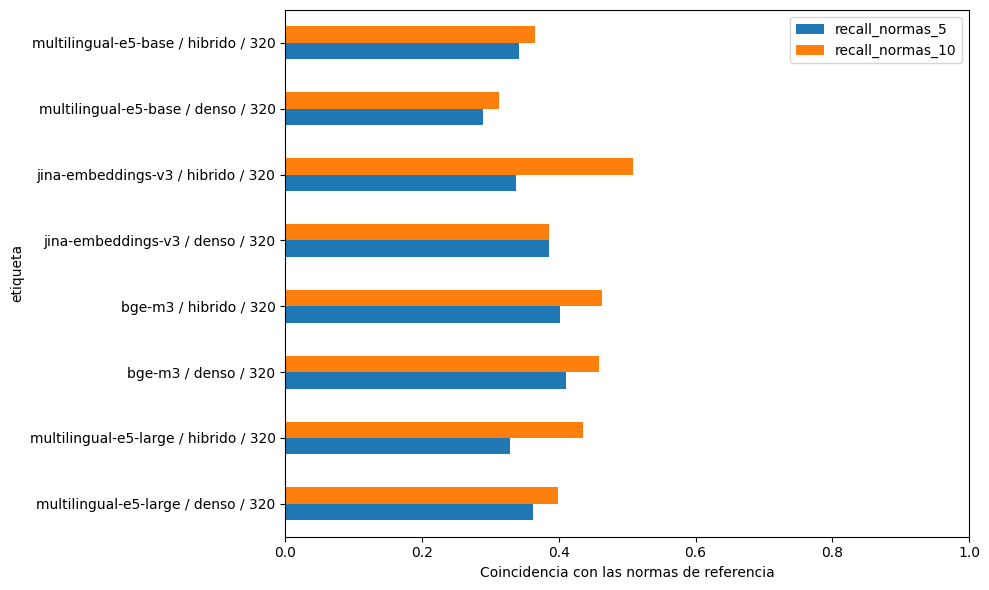

In [5]:
display(resultados.sort_values(["recall_normas_10", "recall_normas_5", "mediana_s"], ascending=[False, False, True]))
grafica = resultados.assign(etiqueta=resultados.modelo + " / " + resultados.metodo + " / " + resultados.tamano.astype(str))
grafica.set_index("etiqueta")[["recall_normas_5", "recall_normas_10"]].plot.barh(figsize=(10, 6), xlim=(0, 1))
plt.xlabel("Coincidencia con las normas de referencia")
plt.tight_layout()
plt.show()

## Resultados

Se completaron las 8 combinaciones de 4 encoders y 2 métodos de recuperación sobre las 50 preguntas. La métrica de normas se calcula sobre 41 preguntas con referencias extraíbles. Las otras 9 no se cuentan como aciertos ni como errores en esa métrica.

La ejecución fue en una NVIDIA L4 de 23034 MiB, con float16, lotes de 4, ventanas de 320 tokens y solapamiento de 32. Estos tiempos corresponden a esa ejecución, no a una A100.

| Encoder | Búsqueda | Recall de normas @5 | Recall de normas @10 | Mediana por consulta |
|---|---|---:|---:|---:|
| BGE-M3 | Densa | 41.06 % | 45.93 % | 0.107 s |
| BGE-M3 | Híbrida | 40.24 % | 46.34 % | 1.257 s |
| Jina v3 | Densa | 38.62 % | 38.62 % | 0.198 s |
| E5-large | Densa | 36.18 % | 39.84 % | 0.110 s |
| E5-base | Híbrida | 34.15 % | 36.59 % | 1.236 s |
| Jina v3 | Híbrida | 33.74 % | 50.81 % | 1.351 s |
| E5-large | Híbrida | 32.93 % | 43.50 % | 1.260 s |
| E5-base | Densa | 28.86 % | 31.30 % | 0.084 s |

Recall de normas es el promedio de la proporción de normas de referencia recuperadas por pregunta. No representa el porcentaje de respuestas correctas ni comprueba que se haya encontrado el artículo necesario.

BGE-M3 denso obtuvo el mejor resultado en los primeros 5 puestos. Esa es la comparación más cercana al flujo actual, porque 02 selecciona hasta 5 artículos para el decoder. Superó a Jina híbrido por 7.32 puntos porcentuales en @5. Jina híbrido ganó en @10, pero parte de esa ventaja queda fuera de los 5 artículos seleccionados. Jina denso ganó en @1 con 28.86 %.

Con BGE-M3, la búsqueda híbrida mejoró @10 en 0.41 puntos y redujo @5 en 0.81 puntos. Su mediana fue unas 11.7 veces mayor que la búsqueda densa. Estas diferencias de recuperación son pequeñas y no demuestran una ventaja estadística. La indexación de BGE-M3 tomó 15.76 minutos y la de Jina 40.15 minutos, sin incluir la descarga previa de los modelos.

El aviso de E5 sobre 1373 tokens aparece al tokenizar unidades largas antes de dividirlas en ventanas. El código limita las ventanas y comprueba la longitud antes de enviarlas al encoder. La ejecución terminó las 8 combinaciones sin una excepción registrada.

## Decisiones

1. Elegir BGE-M3 con búsqueda densa para la siguiente etapa. Es la mejor opción observada con 5 artículos y tiene licencia MIT según su [ficha oficial](https://huggingface.co/BAAI/bge-m3).
2. Mantener ventanas de 320 tokens, solapamiento de 32 y hasta 5 artículos. En 02 usar encoder_elegido = "bge-m3" e hibrido = False. Reutilizar el índice guardado de esta ejecución.
3. Comparar los decoders con esa misma evidencia. La elección del encoder se confirma con la calidad de las respuestas y el evaluador oficial.
4. Conservar Jina híbrido como alternativa si después se prueba recuperar más candidatos y reordenarlos. Su ventaja en @10 justifica conservarlo, pero todavía no se ha medido ese flujo.
5. Revisar los casos fallidos antes de ampliar el corpus. La tabla agregada no permite separar ausencia de fuentes, fallos de recuperación o referencias problemáticas. Los archivos por pregunta guardados en Drive permiten hacer esa revisión.

La elección se basa en una ejecución y en la muestra de desarrollo. No se midió todavía el puntaje final ni se puede asegurar que este orden se mantenga en las preguntas de la competencia.
